In [1]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
from torch.utils.data import DataLoader
import torch 

/home/tjdu/micromamba/envs/solar-forecasting-hk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.utils import (
    stratified_split_grouped_by_time,
    make_labels,
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    evaluate_table_metrics
)
from src.plot import(
    plot_full_images_from_loader,plot_rmse_extremes_with_time_and_ghi
)
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.model_Twin import(TwinFiLMUNetTiny_SpatialMoE)

In [3]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_30mins_new_fuzzy_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [ ]:
# run it once to build the combined tensor with elevation and landmask, then save it as a new npz file for future use
# shape, out = build_band_tensor_with_elevation(
#     bands_npz_name=bands_npz_name,
#     elevation_npz_name=elevation_npz_name,
#     bands_used=bands_used,
#     output_path="Data/output/new_combined_10mins_with_elev_landmask_fuzzy.npz",
# )
# print("Saved:", out)
# print("Final shape:", shape)

Load X,Y data

In [4]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/new_combined_10mins_with_elev_landmask_fuzzy.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=False,
)
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz")
t = cams["time_min"]
cams_data = cams["data"]
print("paired samples:", len(t))
print("unique CAMS times:", len(np.unique(t)))

paired samples: 67638
unique CAMS times: 46277


Load time stamp

In [5]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz")
t = cams["time_min"]
cams_data = cams["data"]
print("paired samples:", len(t))
print("unique CAMS times:", len(np.unique(t)))
print("duplicates exist:", len(t) != len(np.unique(t)))

paired samples: 67638
unique CAMS times: 46277
duplicates exist: True


In [6]:
c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_split_grouped_by_time(labels, t, 0.8, 0.1, 0.1, seed=42)
T = X.shape[0]
X_test,  y_test  = X[idx_test],  y[idx_test]

In [7]:
minmax =  np.load("Data/static/minmax_strat_stats_day_30mins_no_twillight_fuzzy_new_split.npz")
channel_min, channel_max = minmax["channel_min"], minmax["channel_max"]

In [8]:
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
batch_size = 64
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
model = TwinFiLMUNetTiny_SpatialMoE(feature_size=64, K=2, gate_temp=0.5).to(device)
PATH = "Model_checkpoint/best_moe_easy_good.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)
# print temp of the gating network
print("Gating network temperature:", model.gate_temp)


Gating network temperature: 0.5


In [12]:
# get the clear-sky GHI for the test set
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)
ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
time_mins = cams["time_min"] 
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)

In [13]:
df_results = evaluate_table_metrics(
    model, 
    test_loader, 
    device, 
    cs_ghi_full=c1, 
    time_mins_full=time_mins, 
    idx_eval=idx_test
)

display(df_results)

RMSE  rRMSE (%)        MAE       MBE        R2
Target Category / Period                                                     
CSI    Clear sky           0.058814   6.361044   0.029333  0.002754  0.801713
       Cloudy sky          0.101286  44.685726   0.071073  0.010675  0.584396
       Morning (5-8)       0.124283  17.416612   0.075138 -0.005657  0.833386
       Day (8-16)          0.081306  11.662442   0.049409  0.003139  0.933432
       Evening (16-19)     0.100509  14.415968   0.062275  0.002110  0.895370
       Overall (All sky)   0.088889  12.725156   0.053598  0.002244  0.919653
GHI    Clear sky          36.465481   6.607553  16.845308  1.800518  0.978962
       Cloudy sky         57.569679  45.063473  38.240127  8.038481  0.724787
       Morning (5-8)      28.885492  17.526460  16.823689  0.093185  0.904229
       Day (8-16)         57.375638  11.859860  33.636900  2.771510  0.953707
       Evening (16-19)    25.370011  13.225471  15.503158  1.773815  0.963169
       Overall (All sky)  51.628739  12.569973  29.348737  2.389950  0.964019

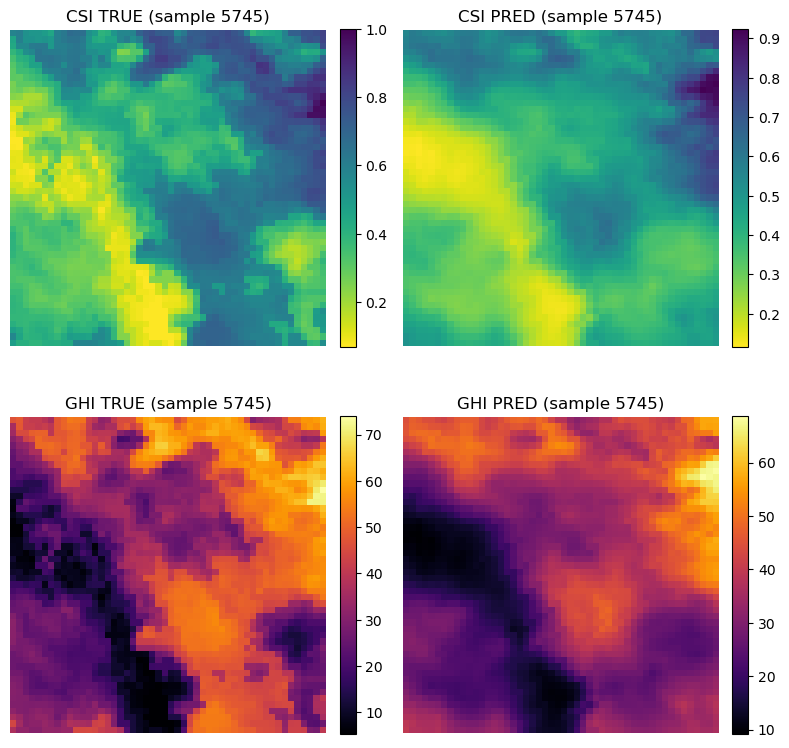

In [12]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=1,
    seed=0
)

In [14]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
def pad_to_32(x):
    # x: (B,C,H,W)
    h, w = x.shape[-2:]
    new_h = ((h + 31) // 32) * 32
    new_w = ((w + 31) // 32) * 32
    pad_h = new_h - h
    pad_w = new_w - w
    # pad format: (left, right, top, bottom)
    x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")
    return x, h, w

def crop_back(x, h, w):
    return x[..., :h, :w]


/tmp/ipykernel_516605/1275622030.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_experts = plt.cm.get_cmap('coolwarm', g_crop.shape[1])


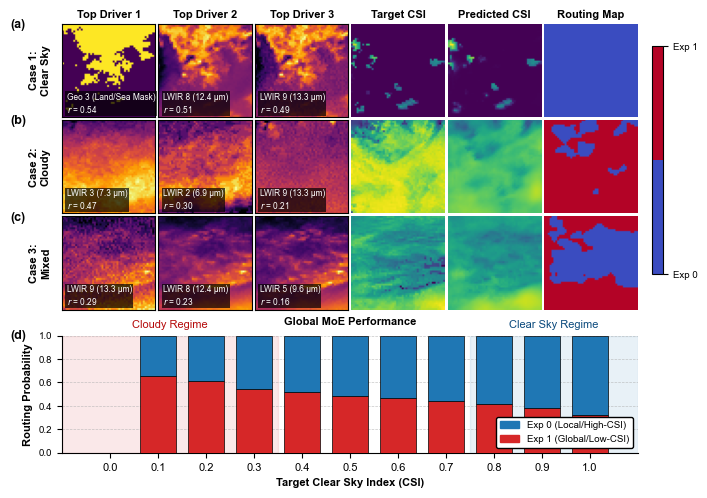

In [66]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.stats import pearsonr
import matplotlib.patches as mpatches

@torch.no_grad()
def plot_publication_moe_proof_ultimate(model, loader, device):
    model.eval()
    
    # --------------------------------------------------------
    # 0. GLOBAL JOURNAL SETTINGS
    # --------------------------------------------------------
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 8,             
        "axes.titlesize": 8,        
        "axes.labelsize": 8,        
        "xtick.labelsize": 7,       
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })
    
    # 1. Forward Pass on one batch
    xb, yb = next(iter(loader))
    xb = xb.to(device)
    yb = yb.to(device)
    
    xb_pad, h, w = pad_to_32(xb)
    out = model(xb_pad)
    
    if isinstance(out, (tuple, list)) and len(out) == 2:
        y_hat, g = out
    else:
        print("Error: Model did not return (prediction, gate).")
        return
        
    y_hat = crop_back(y_hat, h, w).cpu().numpy().squeeze()
    g_crop = crop_back(g, h, w)
    yb_cpu = yb.cpu().numpy().squeeze()
    xb_cpu = xb.cpu().numpy()
    
    gate_probs = torch.softmax(g_crop, dim=1).cpu().numpy()
    expert0_prob = gate_probs[:, 0, :, :]
    expert1_prob = gate_probs[:, 1, :, :]
    routing_map = g_crop.argmax(dim=1).cpu().numpy()
    
    # --- 2. SMART AUTO-FIND ---
    mean_probs_1 = expert1_prob.mean(axis=(1, 2))
    idx_expert0 = np.argmin(mean_probs_1)           
    
    top_exp1_candidates = np.argsort(mean_probs_1)[-15:] 
    variances = [np.var(yb_cpu[i]) for i in top_exp1_candidates]
    idx_expert1 = top_exp1_candidates[np.argsort(variances)[-2]] 
    
    idx_mixed = np.argmin(np.abs(mean_probs_1 - 0.5)) 
    
    indices = [idx_expert0, idx_expert1, idx_mixed]
    
    row_labels = [
        "Case 1:\nClear Sky",
        "Case 2:\nCloudy",
        "Case 3:\nMixed"
    ]
    
    band_names = {
        0: 'LWIR 1 (6.2 μm)', 1: 'LWIR 2 (6.9 μm)', 2: 'LWIR 3 (7.3 μm)', 
        3: 'LWIR 4 (8.6 μm)', 4: 'LWIR 5 (9.6 μm)', 5: 'LWIR 6 (10.4 μm)', 
        6: 'LWIR 7 (11.2 μm)', 7: 'LWIR 8 (12.4 μm)', 8: 'LWIR 9 (13.3 μm)',
        9: 'Geo 1 (SZA)', 10: 'Geo 2 (Elevation)', 11: 'Geo 3 (Land/Sea Mask)'
    }
    num_channels = xb.shape[1]

    def get_top_3_drivers(img_idx, target_prob):
        corrs = []
        flat_prob = target_prob.flatten()
        if np.std(flat_prob) < 1e-6:
            flat_prob = flat_prob + np.random.normal(0, 1e-6, flat_prob.shape)
            
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for c in range(num_channels):
                flat_c = xb_cpu[img_idx, c, :, :].flatten()
                if np.std(flat_c) < 1e-6:
                    corrs.append(0.0)
                else:
                    r, _ = pearsonr(flat_c, flat_prob)
                    corrs.append(r if not np.isnan(r) else 0.0)
        
        top_3_idx = np.argsort(corrs)[-3:][::-1]
        return top_3_idx, [corrs[i] for i in top_3_idx]
    
    # --- 3. PLOTTING SETUP (THE PRECISION LAYOUT) ---
    fig = plt.figure(figsize=(7.2, 6.5)) 
    
    # By pulling the "bottom" up to 0.52, the grid cells become perfect squares.
    # Now, wspace=0.02 and hspace=0.02 will actually make the images touch!
    gs_top = fig.add_gridspec(3, 6, left=0.08, right=0.88, top=0.96, bottom=0.52, wspace=0.03, hspace=0.03)
    
    # We move the bar chart up to fill the newly created empty space
    gs_bot = fig.add_gridspec(1, 1, left=0.08, right=0.88, top=0.48, bottom=0.3)
    
    cmap_experts = plt.cm.get_cmap('coolwarm', g_crop.shape[1])
    panel_labels = ['(a)', '(b)', '(c)']
    
    for row, idx in enumerate(indices):
        
        if row == 0:
            target_prob = expert0_prob[idx]
        else:
            target_prob = expert1_prob[idx]
            
        top_3_channels, top_3_corrs = get_top_3_drivers(idx, target_prob)
        
        # 1. Plot the Top 3 Driver Channels
        for col in range(3):
            c_idx = top_3_channels[col]
            r_val = top_3_corrs[col]
            
            ax = fig.add_subplot(gs_top[row, col])
            cmap = 'viridis' if 'Geo' in band_names[c_idx] else 'inferno'
            im = ax.imshow(xb_cpu[idx, c_idx], cmap=cmap)
            
            if col == 0:
                ax.set_ylabel(row_labels[row], fontweight='bold', fontsize=8, labelpad=8)
                ax.text(-0.55, 1.05, panel_labels[row], transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')
            
            if row == 0:
                ax.set_title(f"Top Driver {col+1}", fontweight='bold', pad=4)
            
            box_text = f"{band_names[c_idx]}\n$r$ = {r_val:.2f}"
            ax.text(0.05, 0.05, box_text, transform=ax.transAxes, color='white', 
                    fontsize=6, bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=1))
            ax.set_xticks([]); ax.set_yticks([])

        csi_true = yb_cpu[idx]
        csi_pred = y_hat[idx]
        vmin_csi = min(csi_true.min(), csi_pred.min())
        vmax_csi = max(csi_true.max(), csi_pred.max())

        # 2. Target Y 
        ax_true = fig.add_subplot(gs_top[row, 3])
        im_true = ax_true.imshow(csi_true, cmap='viridis_r', vmin=vmin_csi, vmax=vmax_csi)
        ax_true.axis('off')
        if row == 0: ax_true.set_title("Target CSI", fontweight='bold', pad=4)
        
        # 3. Predicted Y 
        ax_pred = fig.add_subplot(gs_top[row, 4])
        im_pred = ax_pred.imshow(csi_pred, cmap='viridis_r', vmin=vmin_csi, vmax=vmax_csi)
        ax_pred.axis('off')
        if row == 0: ax_pred.set_title("Predicted CSI", fontweight='bold', pad=4)
        
        # 4. Routing Map 
        ax_gate = fig.add_subplot(gs_top[row, 5])
        im_gate = ax_gate.imshow(routing_map[idx], cmap=cmap_experts, vmin=0, vmax=1)
        ax_gate.axis('off')
        if row == 0: ax_gate.set_title("Routing Map", fontweight='bold', pad=4)

    # --- 4. COLORBAR (ABSOLUTE POSITIONING) ---
    # Adjusted slightly to visually center with the new lowered top grid
    cax = fig.add_axes([0.90, 0.575, 0.015, 0.35]) 
    cbar_gate = fig.colorbar(im_gate, cax=cax, ticks=[0, 1])
    cbar_gate.ax.set_yticklabels(['Exp 0', 'Exp 1'], fontsize=7)

    # --- 5. PANEL D: OVERALL ROUTING BARS ---
    flat_y = yb_cpu.flatten()
    flat_e0 = expert0_prob.flatten()
    flat_e1 = expert1_prob.flatten()
    
    bins = np.arange(-0.05, 1.15, 0.1)
    bin_centers = np.arange(0.0, 1.1, 0.1)
    e0_means, e1_means = [], []
    
    for i in range(len(bins)-1):
        mask = (flat_y >= bins[i]) & (flat_y < bins[i+1])
        if np.sum(mask) > 0:
            e0_means.append(np.mean(flat_e0[mask]))
            e1_means.append(np.mean(flat_e1[mask]))
        else:
            e0_means.append(0); e1_means.append(0)

    ax_bar = fig.add_subplot(gs_bot[0, 0])
    
    # TWEAKED: Moved x from -0.05 to -0.09 to prevent overlapping the y-axis label
    # Tweak the 1.05 if the (d) is too close to the row above
    ax_bar.text(-0.09, 1.05, '(d)', transform=ax_bar.transAxes, fontsize=9, fontweight='bold', va='top')
    
    width = 0.075
    ax_bar.bar(bin_centers, e1_means, width=width, color='#d62728', edgecolor='black', linewidth=0.5, zorder=3)
    ax_bar.bar(bin_centers, e0_means, width=width, bottom=e1_means, color='#1f77b4', edgecolor='black', linewidth=0.5, zorder=3)
    
    ax_bar.set_xlim(-0.1, 1.1)
    ax_bar.set_ylim(0, 1.0)
    ax_bar.set_xticks(bin_centers)
    ax_bar.set_xticklabels([f"{x:.1f}" for x in bin_centers], fontsize=8)
    
    ax_bar.set_xlabel("Target Clear Sky Index (CSI)", fontweight='bold')
    ax_bar.set_ylabel("Routing Probability", fontweight='bold')
    
    ax_bar.set_title("Global MoE Performance", fontweight='bold', pad=8)
    
    ax_bar.axvspan(-0.1, 0.35, color='#d62728', alpha=0.1, zorder=0)
    ax_bar.text(0.125, 1.05, "Cloudy Regime", color='#b50a0a', fontsize=8, ha='center', va='bottom')
    
    ax_bar.axvspan(0.75, 1.1, color='#1f77b4', alpha=0.1, zorder=0)
    ax_bar.text(0.925, 1.05, "Clear Sky Regime", color='#0b4a7d', fontsize=8, ha='center', va='bottom')
    
    ax_bar.grid(axis='y', linestyle='--', alpha=0.7, linewidth=0.5, zorder=0)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    
    blue_patch = mpatches.Patch(color='#1f77b4', label='Exp 0 (Local/High-CSI)')
    red_patch = mpatches.Patch(color='#d62728', label='Exp 1 (Global/Low-CSI)')
    
    ax_bar.legend(handles=[blue_patch,red_patch], loc='lower right', fontsize=7, framealpha=1.0, edgecolor='black')
    
    plt.savefig('MoE_Specialization_Proof.pdf', format='pdf', dpi=800, bbox_inches='tight')
    plt.show()

# Run it
plot_publication_moe_proof_ultimate(model, test_loader, device)